In [1]:
from src.models.lstm_decomp_multivariate_forecast import LSTMDecompMultivariateForecast
import datetime
import logging
import os
import pandas as pd
from ts_toolkit.metrics import global_metrics, daily_mae
from ts_toolkit.viz import plot_history_forecast


In [2]:
import logging
import os

model_name = "lstm_multivar_decomp_cad_v1_20241125_20241211"

os.makedirs(f"plots/{model_name}", exist_ok=True)
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(f"plots/{model_name}/results.log"),
        logging.StreamHandler()
    ]
)


In [3]:
from src.data_loader import fetch_frame
# df = fetch_frame()
df = fetch_frame(
    start_date="2024-11-25 18:00:00",
    end_date  ="2024-12-11 12:10:00",
    use_cache=True,             # всегда тянуть свежие данные
    cache_filename="multivar_9001_20241125_20241211.parquet",
    # verbose=True                 # чтобы видеть прогресс
)
df.rename(columns={'common_cad_avg1h_instance_consumer_from_ws_with_metrics:8000_job_consumer_from_ws_with_metrics_service_castle': 'common_cad_avg1h'}, inplace=True)
df.rename(columns={'db_insert_cad_avg1h_instance_10.201.92.176:8010_job_consumer_ml_to_db_service_castle': 'db_insert_cad_avg1h'}, inplace=True)
df.rename(columns={'kafka_network_cad_avg1h_instance_10.201.92.176:8010_job_consumer_ml_to_db_service_castle': 'kafka_network_cad_avg1h'}, inplace=True)
df.rename(columns={'counter_events_total_instance_consumer_from_ws_with_metrics:8000_job_consumer_from_ws_with_metrics_service_castle': 'counter_events_total'}, inplace=True)

print(df.head())

print(df.info())

print(df.describe())

print(df.isnull().sum())


                     common_cad_avg1h  db_insert_cad_avg1h  \
ts                                                           
2024-11-25 18:00:30               NaN             3.053300   
2024-11-25 18:00:45               NaN             3.053300   
2024-11-25 18:01:00        570.036987             3.053300   
2024-11-25 18:01:15        570.036987             3.053300   
2024-11-25 18:01:30        570.036987             3.013525   

                     kafka_network_cad_avg1h  counter_events_total  
ts                                                                  
2024-11-25 18:00:30                420.23265                   NaN  
2024-11-25 18:00:45                420.23265                   NaN  
2024-11-25 18:01:00                420.23265            10639901.0  
2024-11-25 18:01:15                420.23265            10639901.0  
2024-11-25 18:01:30                390.79950            10639901.0  
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90759 entries, 2024-11-25 18:

In [4]:
df.info()
df.dropna(inplace=True)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90759 entries, 2024-11-25 18:00:30 to 2024-12-11 12:10:00
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   common_cad_avg1h         90757 non-null  float64
 1   db_insert_cad_avg1h      90571 non-null  float64
 2   kafka_network_cad_avg1h  90571 non-null  float64
 3   counter_events_total     90543 non-null  float64
dtypes: float64(4)
memory usage: 3.5 MB


In [5]:
logging.info(df.head())
logging.info(df.info())
logging.info(df.describe())
logging.info(df.isnull().sum())

2025-06-17 21:42:02,814 - INFO -                      common_cad_avg1h  db_insert_cad_avg1h  \
ts                                                           
2024-11-25 18:01:00        570.036987             3.053300   
2024-11-25 18:01:15        570.036987             3.053300   
2024-11-25 18:01:30        570.036987             3.013525   
2024-11-25 18:01:45        570.036987             3.013525   
2024-11-25 18:02:00        777.154144             3.013525   

                     kafka_network_cad_avg1h  counter_events_total  
ts                                                                  
2024-11-25 18:01:00                420.23265            10639901.0  
2024-11-25 18:01:15                420.23265            10639901.0  
2024-11-25 18:01:30                390.79950            10639901.0  
2024-11-25 18:01:45                390.79950            10639901.0  
2024-11-25 18:02:00                390.79950            10641497.0  
2025-06-17 21:42:02,831 - INFO - None
2025-06-17 

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90543 entries, 2024-11-25 18:01:00 to 2024-12-11 11:16:30
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   common_cad_avg1h         90543 non-null  float64
 1   db_insert_cad_avg1h      90543 non-null  float64
 2   kafka_network_cad_avg1h  90543 non-null  float64
 3   counter_events_total     90543 non-null  float64
dtypes: float64(4)
memory usage: 3.5 MB


In [6]:
H = 900                               # горизонт
df_train = df.iloc[:-H]               # всё кроме последних 900
df_hold  = df.iloc[-H:]               # отложенный «будущий» хвост
assert len(df_hold) == H

logging.info(f"Длина df_train: {len(df_train)}")
logging.info(f"Длина df_hold: {len(df_hold)}")

2025-06-17 21:42:02,896 - INFO - Длина df_train: 89643
2025-06-17 21:42:02,898 - INFO - Длина df_hold: 900


In [8]:

model = LSTMDecompMultivariateForecast(
    target_col="common_cad_avg1h",
    horizon=900,
    seq_len=5760,
    hidden_size=128,
    n_epochs=3,
    device="cuda:1"
)
model.fit(df_train)              # df — полный мультивариативный ряд

/home/borovets.av/kolya/realtime_anomaly_analytics/src/models/lstm_decomp_multivariate_forecast.py:105: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df.fillna(method="ffill").fillna(method="bfill")
/home/borovets.av/kolya/realtime_anomaly_analytics/src/models/lstm_decomp_multivariate_forecast.py:169: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=self.use_amp)
/home/borovets.av/kolya/realtime_anomaly_analytics/src/models/lstm_decomp_multivariate_forecast.py:178: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.use_amp):
/home/borovets.av/kolya/realtime_anomaly_analytics/src/models/lstm_decomp_multivariate_forecast.py:193: FutureWarning: `torch.

[Ep 1/3] train=0.11801 val=0.43414
[Ep 2/3] train=0.05170 val=0.37484
[Ep 3/3] train=0.04836 val=0.33636


In [9]:
y_pred_series = model.predict(df_train)   # Series на 900 будущих шагов

/home/borovets.av/kolya/realtime_anomaly_analytics/src/models/lstm_multivariate_forecast.py:210: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  last_seq = last_seq.fillna(method="ffill").fillna(method="bfill")


In [10]:
# ───────── 2. сравнение с фактом ─────────
pred_idx = y_pred_series.index
y_true = df_hold["common_cad_avg1h"].reindex(pred_idx).dropna()
y_pred = y_pred_series.reindex(y_true.index).dropna()   # выравниваем

logging.info(f"Длина прогноза: {len(y_pred)}, Длина факта: {len(y_true)}")

metrics = global_metrics(y_true, y_pred)
logging.info(
    f"Blind ~4h test • MAE={metrics['MAE']:.1f}  "
    f"RMSE={metrics['RMSE']:.1f}  MAPE={metrics['MAPE']:.2f}%  "
    f"on {len(y_true)} valid points"
)

2025-06-17 21:31:54,980 - INFO - Длина прогноза: 900, Длина факта: 900
2025-06-17 21:31:54,984 - INFO - Blind ~4h test • MAE=33.5  RMSE=42.8  MAPE=8.72%  on 900 valid points


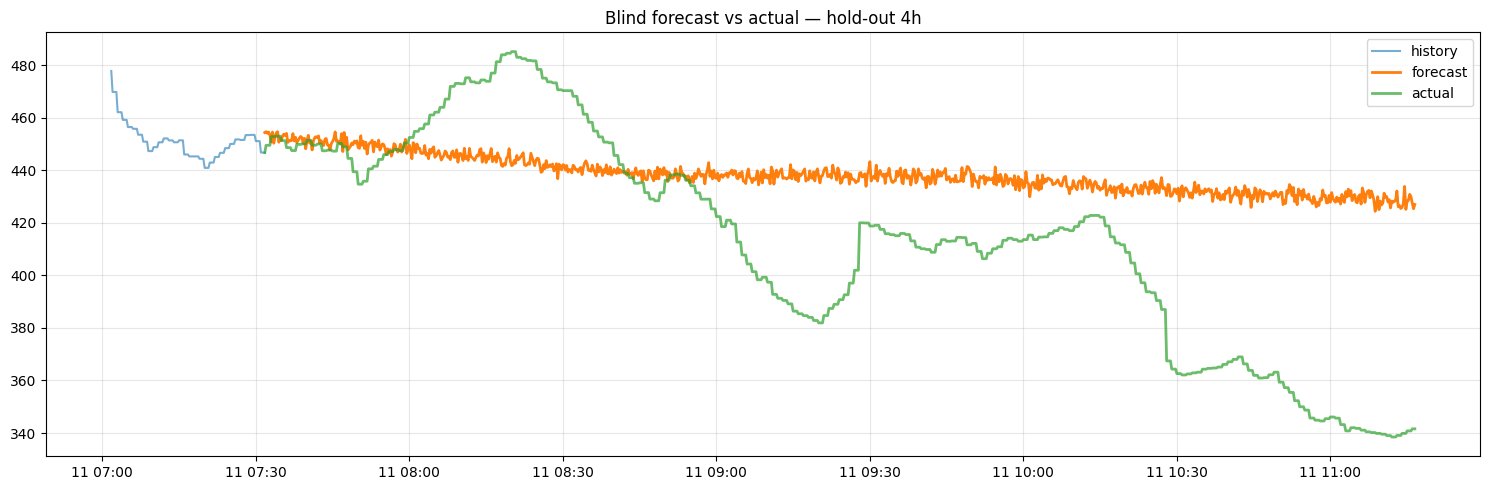

In [11]:
hist_start = pred_idx[0] - pd.Timedelta(minutes=30)
plot_history_forecast(
    history  = df.loc[hist_start:pred_idx[0], "common_cad_avg1h"],
    forecast = pd.Series(y_pred, index=pred_idx),
    actual   = y_true,
    title    = "Blind forecast vs actual — hold-out 4h",
    filename = f"plots/{model_name}/final_hold_out_forecast_{datetime.datetime.now():%Y%m%d_%H%M%S}.png",
)

2025-06-17 21:31:55,676 - INFO - 
*** Hold-out metrics ***
2025-06-17 21:31:55,677 - INFO -           value
MAE   33.466626
RMSE  42.750749
MAPE   8.722659
2025-06-17 21:31:55,687 - INFO - 
MAE by day:
2025-06-17 21:31:55,688 - INFO -         index        MAE
0  2024-12-11  33.466626


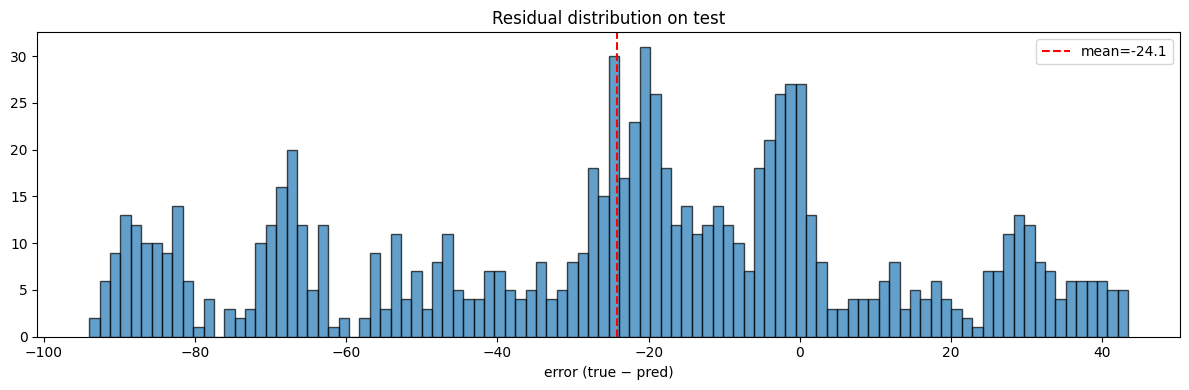

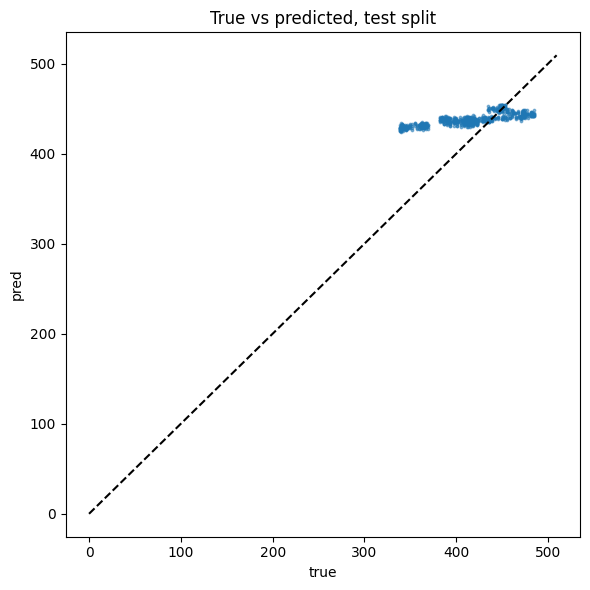

In [12]:
resid = y_true - y_pred

# 3.1 сводные метрики
metrics_df = pd.DataFrame([metrics]).T.rename(columns={0: "value"})
logging.info("\n*** Hold-out metrics ***")
logging.info(metrics_df)

# 3.2 метрики по суткам
daily_mae_result = daily_mae(y_true, y_pred)
logging.info("\nMAE by day:")
logging.info(daily_mae_result.tail())

# 3.3 распределение ошибок
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.hist(resid, bins=100, alpha=.7, edgecolor="black")
plt.axvline(resid.mean(), color="r", linestyle="--", label=f"mean={resid.mean():.1f}")
plt.title("Residual distribution on test"); plt.xlabel("error (true − pred)")
plt.legend(); plt.tight_layout()
plt.savefig(f"plots/{model_name}/residual_distribution_{datetime.datetime.now():%Y%m%d_%H%M%S}.png")

# 3.4 scatter true vs pred
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, s=3, alpha=0.5)
lim = [0, max(y_true.max(), y_pred.max())*1.05]
plt.plot(lim, lim, "k--")
plt.xlabel("true"); plt.ylabel("pred")
plt.title("True vs predicted, test split")
plt.tight_layout()
plt.savefig(f"plots/{model_name}/true_vs_pred_scatter_{datetime.datetime.now():%Y%m%d_%H%M%S}.png")